# Importing modules and settings

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
from matplotlib.pyplot import rc_context

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

General settings of Scanpy

In [5]:
sc.settings.verbosity = 3 
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')


scanpy==1.9.1 anndata==0.9.1 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.4.2 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


In [6]:
umap_cmap = sns.blend_palette(['xkcd:light grey', 'xkcd:azure'], as_cmap = True)

# Declaring the input and output files

In [7]:
results_file = './Serotonergic_data_annotated.h5ad'

In [8]:
adata = sc.read_h5ad('./Serotonergic_data_labels_transferred.h5ad')

In [9]:
adata

AnnData object with n_obs × n_vars = 47292 × 24000
    obs: 'sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio', 'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'ingest_names', 'transferred'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'biological_replicates', 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'ingest_names_colors', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_3_colors', 'leiden_4_colors', 'library_colors', 'log1p', 'nei

In [10]:
leiden_names = adata.obs.columns[adata.obs.columns.str.contains('leiden')].to_list()

In [11]:
leiden_names

['leiden_1', 'leiden_2', 'leiden_3', 'leiden_4']

In [12]:
adata.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000008,h1SMcG0000008,Gene Expression,h1SMcT0000008.1,hconf,SMEST029651001.1,SMEST029651001.1,dd_Smed_v6_35379_0_1,"SMEST029651001.1,SMEST029651002.1,SmMSTRG.9911...","SMEST029651001.1,SMEST029651002.1",dd_Smed_v6_35379_0_1,...,10,0.000232,99.978886,11.0,True,0.000284,0.477953,1.455614,0.000172,0.012502
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,SMEST029652002.1,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",SMEST029652002.1,dd_Smed_v6_5323_0_1,...,196,0.004159,99.586175,197.0,True,0.003342,0.036366,0.147434,0.002345,0.039136
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,SMEST029655001.1,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...","SMEST029655001.1,SMEST029655002.1",dd_Smed_v6_6416_0_1,...,2366,0.053312,95.004539,2525.0,True,0.044958,0.140558,0.456098,0.031060,0.146029
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,SMEST029666001.1,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",SMEST029666001.1,dd_Smed_v6_20296_0_1,...,25,0.000549,99.947216,26.0,True,0.000470,0.185634,0.589633,0.000318,0.015024
h1SMcG0000013,h1SMcG0000013,Gene Expression,h1SMcT0000013.5,hconf,SmMSTRG.9917.1,MSTRG.9917.1,dd_Smed_v6_4708_0_1,"SMEST029667004.1,SmMSTRG.9917.1,SmMSTRG.9917.2...","MSTRG.9917.1,SMEST029667004.1",dd_Smed_v6_4708_0_1,...,681,0.014885,98.562169,705.0,True,0.012562,0.100089,0.336211,0.008670,0.077038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0034970,h1SMnG0034970,Gene Expression,h1SMnT0034970.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000040,0.120145,0.395626,0.000027,0.004380
h1SMnG0035064,h1SMnG0035064,Gene Expression,h1SMnT0035064.1,other,-,-,-,-,-,-,...,1,0.000021,99.997889,1.0,True,0.000026,0.225550,0.707884,0.000017,0.003735
h1SMnG0035227,h1SMnG0035227,Gene Expression,h1SMnT0035227.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000049,0.321466,0.992030,0.000031,0.005060
h1SMnG0035258,h1SMnG0035258,Gene Expression,h1SMnT0035258.1,hconf,-,-,-,-,-,-,...,3,0.000063,99.993666,3.0,True,0.000092,0.375602,1.152403,0.000057,0.007119


In [13]:
adata.obs.columns

Index(['sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio',
       'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'ingest_names',
       'transferred'],
      dtype='object')

# Selecting one clustering layer from leiden_names

In [14]:
clusteringlayer = 'leiden_3'

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


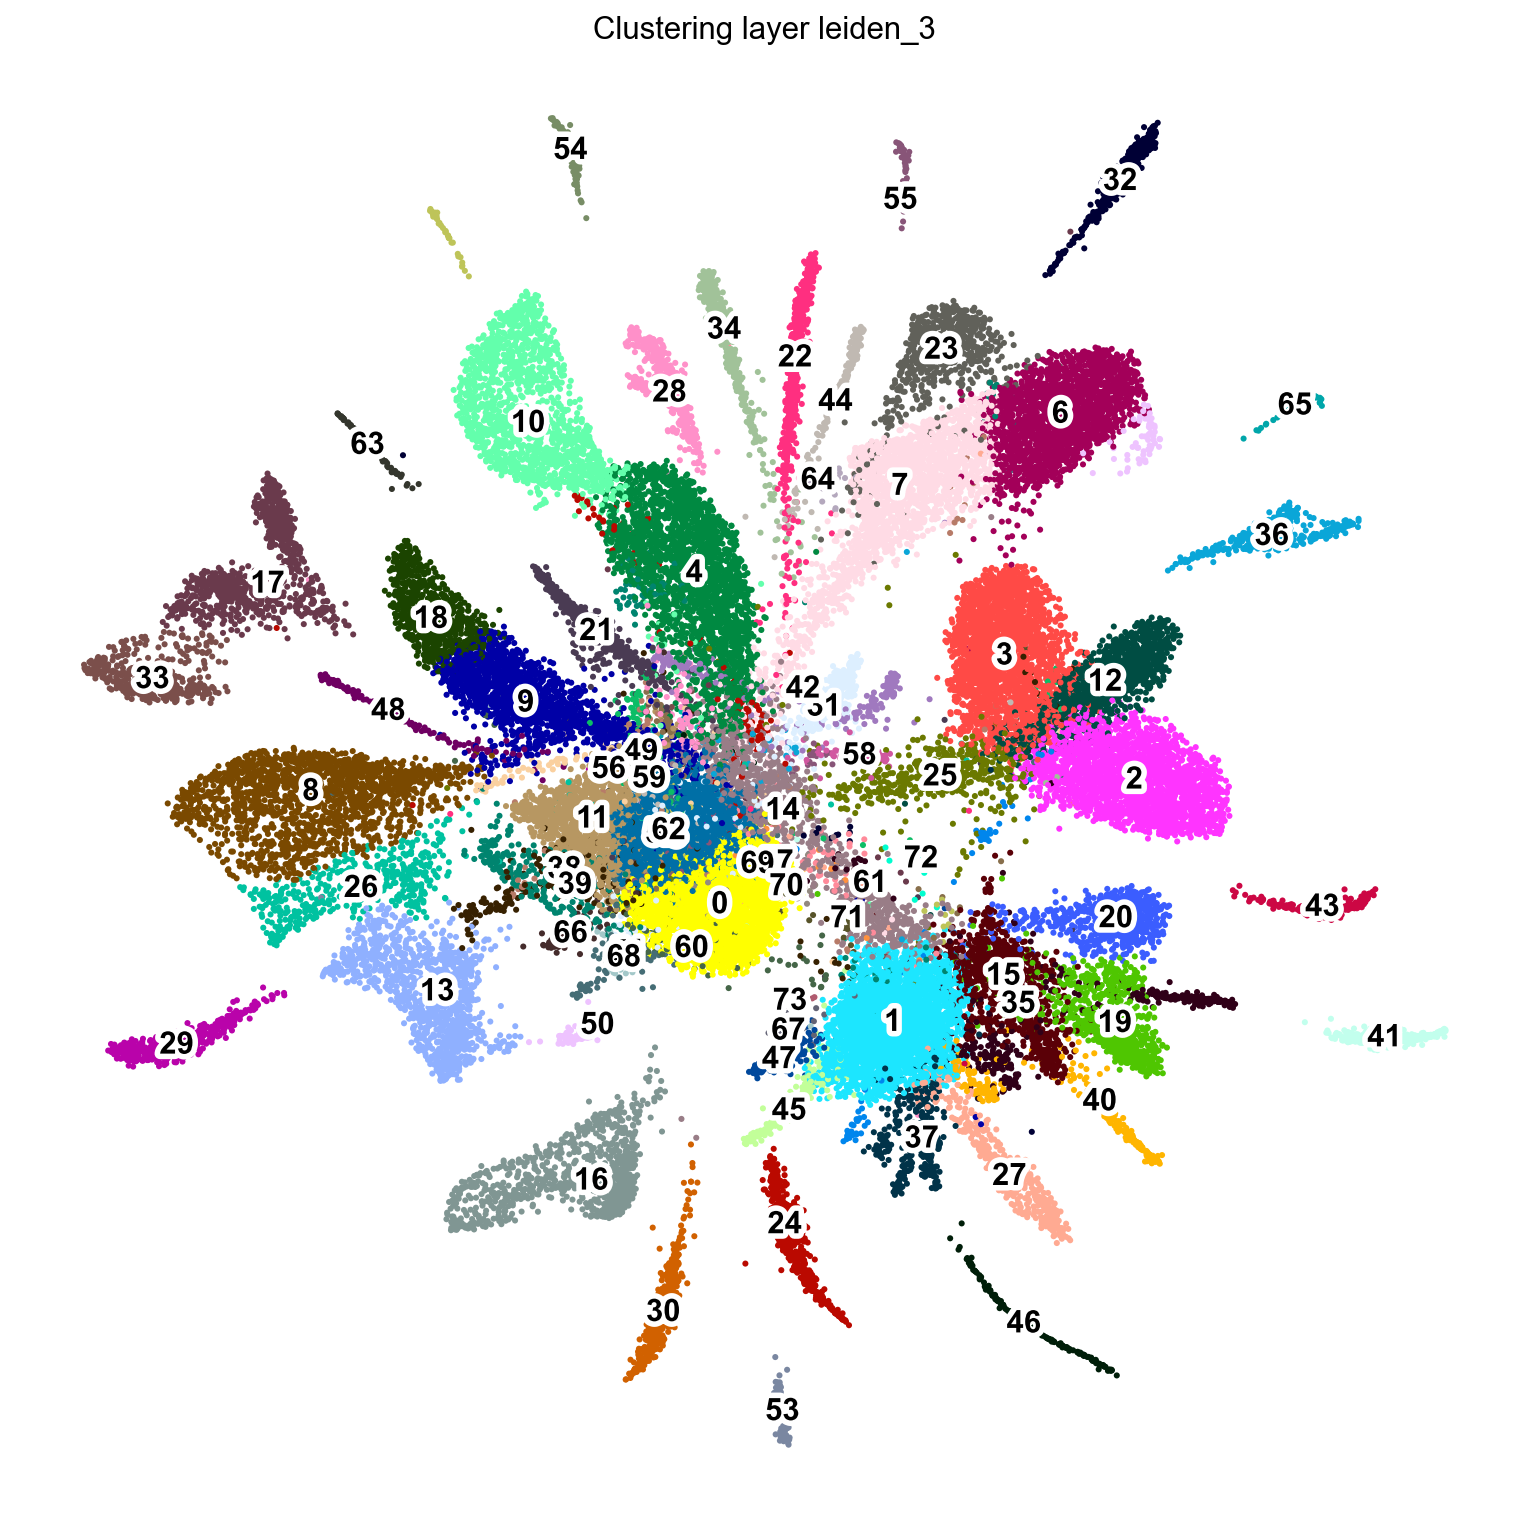

In [15]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color=clusteringlayer, legend_loc='on data', legend_fontoutline = 5,
               title= 'Clustering layer '+str(clusteringlayer), size = 30,
               frameon=False)

# Transferring the cluster names, broad clusters and colours

In [16]:
df = pd.read_excel('./outputs/leiden_3_annotated_clusters_names_broad_groups_colours - neoblast collapsed.xlsx', index_col = 'Cluster ID')

In [17]:
df

,Cluster name,Colour,Cluster name - neoblast collapsed,Colour - neoblast collapsed,Broad group,Diagnostic marker,Cluster order,leiden_3_total,leiden_3_gfp(RNAi)_B1,leiden_3_gfp(RNAi)_B2,...,lhx1/5-1 B1,lhx1/5-1 B2,pitx B1,pitx B2,order,Colour B,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
Cluster ID,,,,,,,,,,,,,,,,,,,,,
0,neoblasts 1,#C8C8C8,neoblasts,#C8C8C8,neoblasts,NaN,0.0,3468,561,724,...,1239,1755,1591,1582,0.0,#969696,NaN,NaN,NaN,#2272b6
1,chat+ neurons 1,#FEC44F,chat+ neurons 1,#FEC44F,neurons,NaN,1.0,3335,606,526,...,1276,1983,1674,1279,1.0,#fcc34f,NaN,NaN,NaN,#1E90FF
2,body wall muscle,#B22222,body wall muscle,#B22222,muscle,NaN,2.0,2410,396,379,...,748,1395,1290,837,2.0,#b22223,NaN,NaN,NaN,#b22223
3,intestinal and DV muscle,#CD5555,intestinal and DV muscle,#CD5555,muscle,NaN,3.0,2404,444,431,...,905,1371,1218,891,3.0,#ed6da6,NaN,NaN,NaN,#969696
4,phagocyte progenitors,#80C480,phagocyte progenitors,#80C480,phagocytes,NaN,4.0,2384,458,441,...,743,1037,1045,866,4.0,#2272b6,NaN,NaN,NaN,#fcc34f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,neoblasts 16,#DED9D9,neoblasts,#C8C8C8,neoblasts,NaN,70.0,22,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,unannotated 1,#E6E6E6,unannotated 1,#E6E6E6,unannotated,NaN,71.0,21,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,unannotated 2,#E6E6E6,unannotated 2,#E6E6E6,unannotated,NaN,72.0,17,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.index.dropna().drop('total')

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
       72, 73],
      dtype='object', name='Cluster ID')

In [19]:
df = df.loc[df.index.dropna().drop('total')]

In [20]:
df.columns

Index(['Cluster name', 'Colour', 'Cluster name - neoblast collapsed',
       'Colour - neoblast collapsed', 'Broad group', 'Diagnostic marker',
       'Cluster order', 'leiden_3_total', 'leiden_3_gfp(RNAi)_B1',
       'leiden_3_gfp(RNAi)_B2', 'leiden_3_lhx1/5-1(RNAi)_B1',
       'leiden_3_lhx1/5-1(RNAi)_B2', 'leiden_3_pitx(RNAi)_B1',
       'leiden_3_pitx(RNAi)_B2', '% total', '% gfp B1', '% gfp B2',
       '% lhx1/5-1 B1', '% lhx1/5-1 B2', '% pitx B1', '% pitx B2',
       'Order Broad', 'Cluster Order Sorted', 'Unnamed: 24', 'Counts Broad',
       'Broad Group', 'total', 'gfp B1', 'gfp B2', 'lhx1/5-1 B1',
       'lhx1/5-1 B2', 'pitx B1', 'pitx B2', 'order', 'Colour B', 'Unnamed: 36',
       'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39'],
      dtype='object')

In [21]:
df.index = df.index.astype('string')

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


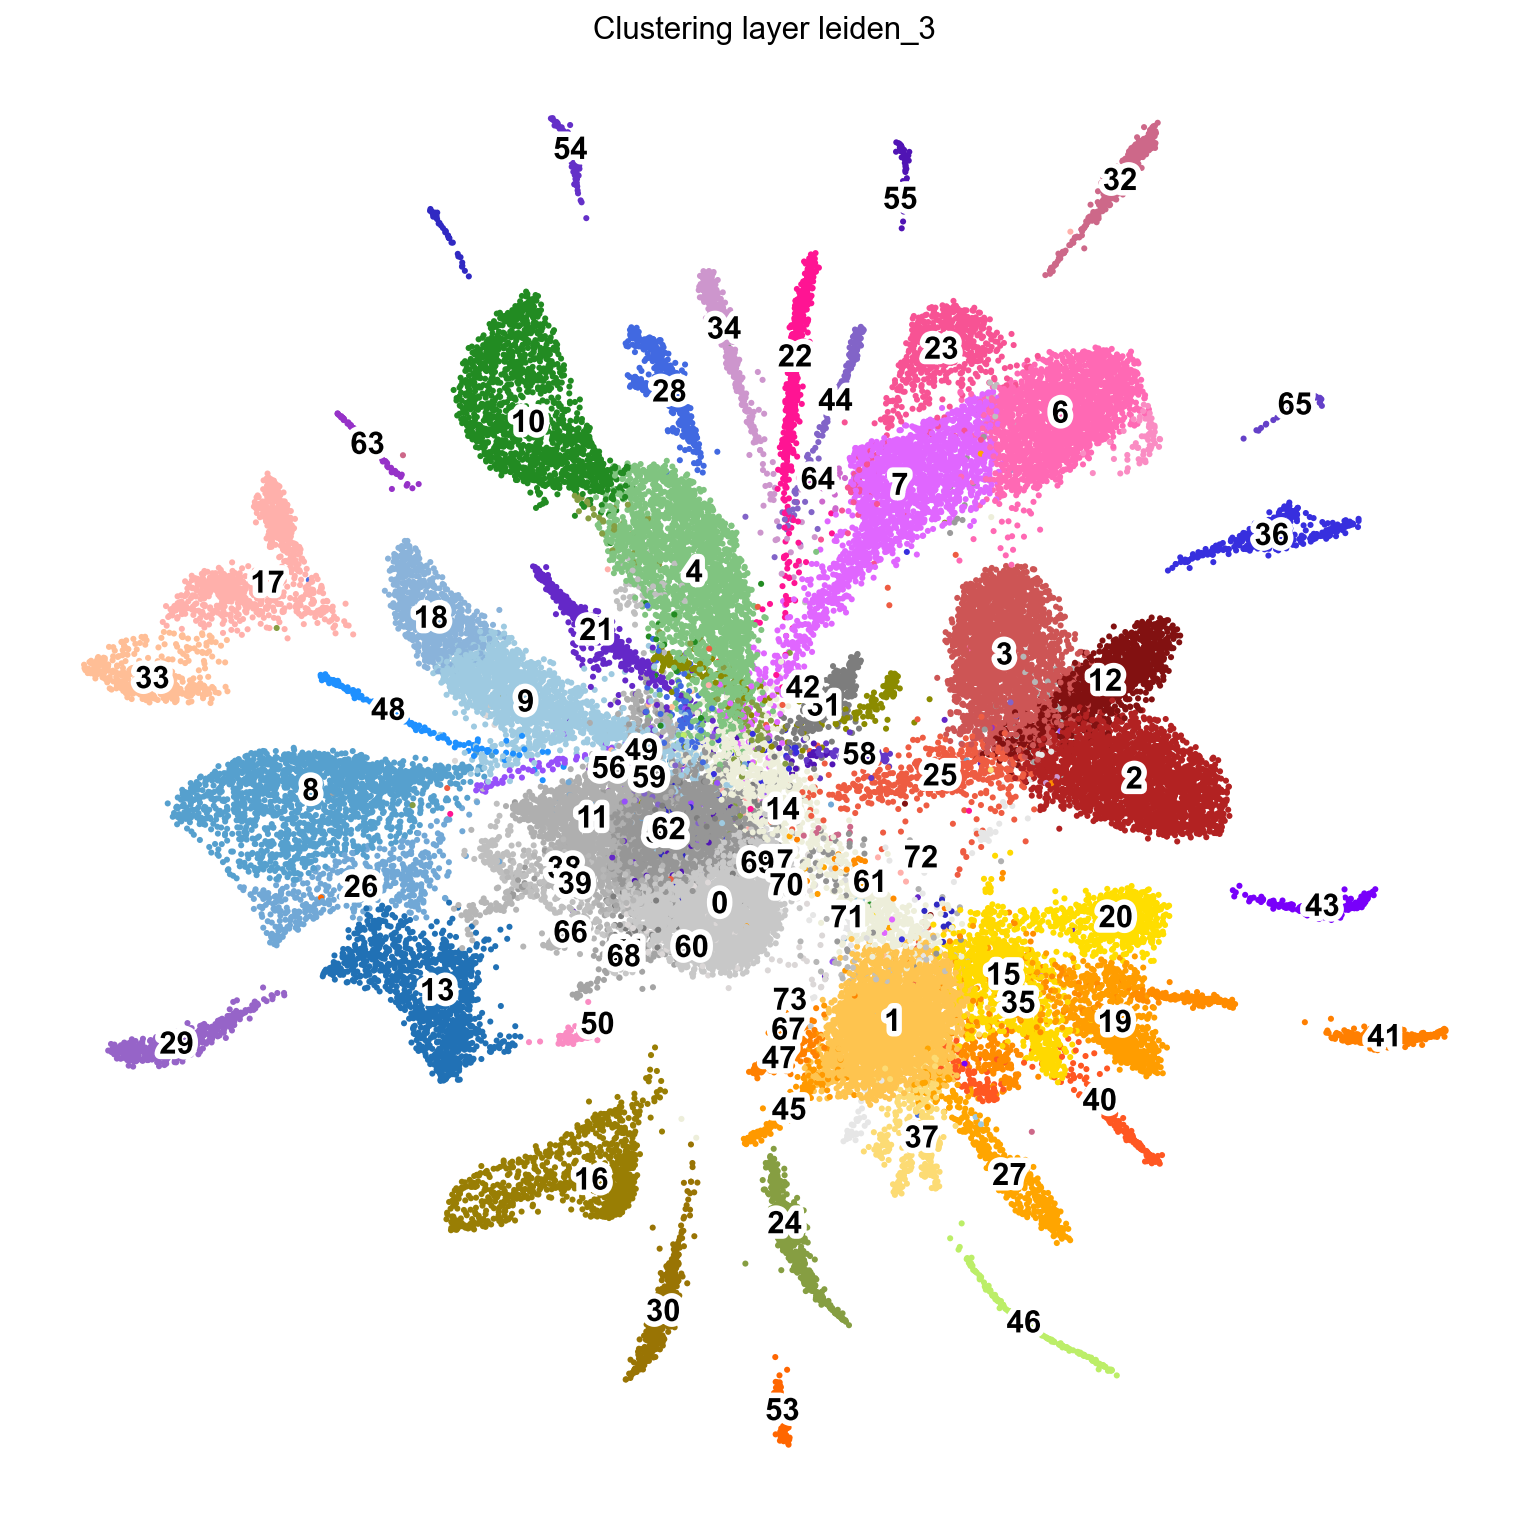

In [22]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color=clusteringlayer, legend_loc='on data', legend_fontoutline = 5,
               title= 'Clustering layer '+str(clusteringlayer), size = 30,
               palette = df['Colour'].to_list(),
               frameon=False)

In [23]:
for i in adata.obs.index:
    adata.obs.loc[i, 'leiden_3_names_collapsed'] = df['Cluster name - neoblast collapsed'][adata.obs.loc[i, clusteringlayer]]
    adata.obs.loc[i, 'leiden_3_names'] = df['Cluster name'][adata.obs.loc[i, clusteringlayer]]
    adata.obs.loc[i, 'broad_names'] = df['Broad group'][adata.obs.loc[i, clusteringlayer]]

In [24]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,0.0,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0.0,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,0.0,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,0.0,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,0.0,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0.0,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,0.0,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons


In [25]:
adata.obs['leiden_3_names']

L43_1_AACCATTGGAGACTAGTAACGCTCGA        pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC                  chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA                      neoblasts 1
L43_1_GACCTTGATAACGCTCGACAAGACTA    early epidermal progenitors 1
L43_1_TTACCTCGACTGGAACAAAGATCGCA         intestinal and DV muscle
                                                ...              
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC                      epidermis 2
L43_5_GGTACCGGCAGAATCTGATGAAGAGA                      neoblasts 3
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA        pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC                  chat+ neurons 1
L43_5_TTCGCCTCCACAAGGAGCAAACATCG                      neoblasts 4
Name: leiden_3_names, Length: 47292, dtype: object

In [26]:
df['Cluster name'].to_list()

['neoblasts 1',
 'chat+ neurons 1',
 'body wall muscle',
 'intestinal and DV muscle',
 'phagocyte progenitors',
 'neoblasts 3',
 'pgrn+ parenchymal cells 2',
 'pgrn+ parenchymal cells 1',
 'late epidermal progenitors',
 'early epidermal progenitors 1',
 'phagocytes',
 'neoblasts 2',
 'muscle pharynx',
 'epidermis 1',
 'neuronal progenitors',
 'chat+ neurons 2',
 'otf+ neurons 1',
 'protonephridia flame cells',
 'early epidermal progenitors 2',
 'celsr-1+ neurons',
 'th+ neurons',
 'secretory 1',
 'psap+ parenchymal cells',
 'ldlrr+ parenchymal cells',
 'basal cells',
 'muscle progenitors',
 'epidermis 2',
 'para+ neurons',
 'pharynx cell type',
 'secretory 2',
 'otf+ neurons 2',
 'germ cell progenitors',
 'pigment cells',
 'protonephridia tubule cells',
 'aqp+ parenchymal cells',
 'trpm-2-1+ neurons',
 'secretory 9',
 'trpa-1+ neurons',
 'neoblasts 4',
 'neoblasts 5',
 'pkd-1+ neurons',
 'tinc+ neurons',
 'goblet cells',
 'secretory 5',
 'secretory 3',
 'tph+ neurons',
 'psd+ cells',
 

In [27]:
adata.obs['leiden_3_names'] = adata.obs['leiden_3_names'].astype('category')

In [28]:
adata.obs['leiden_3_names'].cat.set_categories(df['Cluster name'].to_list(), inplace=True)

C:\Users\19125778\Anaconda3\lib\site-packages\pandas\core\arrays\categorical.py:2747: FutureWarning: The `inplace` parameter in pandas.Categorical.set_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)


In [29]:
adata.obs['leiden_3_names']

L43_1_AACCATTGGAGACTAGTAACGCTCGA        pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC                  chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA                      neoblasts 1
L43_1_GACCTTGATAACGCTCGACAAGACTA    early epidermal progenitors 1
L43_1_TTACCTCGACTGGAACAAAGATCGCA         intestinal and DV muscle
                                                ...              
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC                      epidermis 2
L43_5_GGTACCGGCAGAATCTGATGAAGAGA                      neoblasts 3
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA        pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC                  chat+ neurons 1
L43_5_TTCGCCTCCACAAGGAGCAAACATCG                      neoblasts 4
Name: leiden_3_names, Length: 47292, dtype: category
Categories (74, object): ['neoblasts 1', 'chat+ neurons 1', 'body wall muscle', 'intestinal and DV muscle', ..., 'neoblasts 16', 'unannotated 1', 'unannotated 2', 'unannotated 3']

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


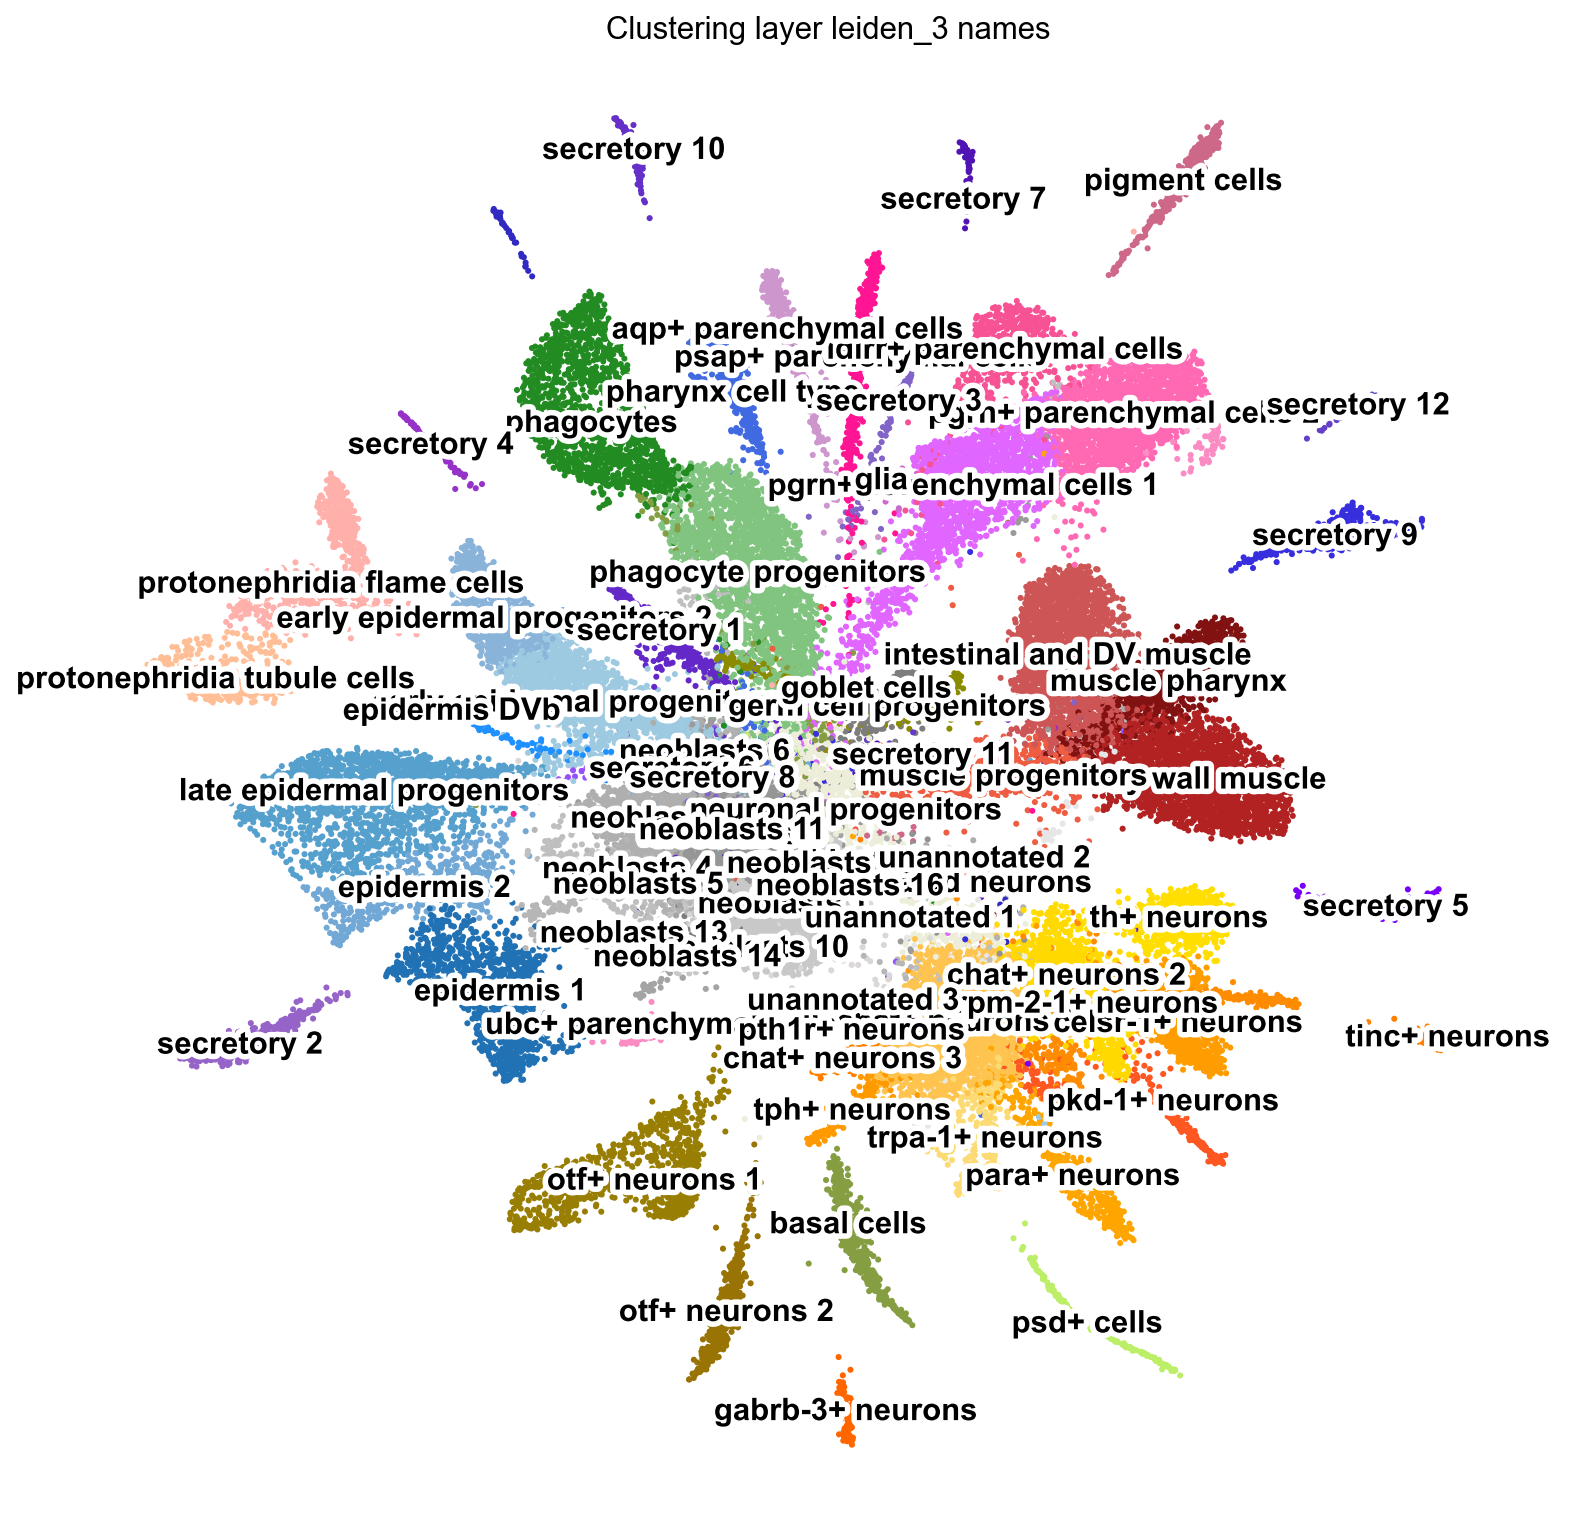

In [30]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color='leiden_3_names', legend_loc='on data', legend_fontoutline = 5,
               title= 'Clustering layer '+str(clusteringlayer)+ ' names', size = 30,
               palette = df['Colour'].to_list(),
               frameon=False)

In [31]:
list(adata.uns)

['biological_replicates',
 'dendrogram_leiden_1',
 'dendrogram_leiden_2',
 'dendrogram_leiden_3',
 'dendrogram_leiden_4',
 'hvg',
 'ingest_names_colors',
 'leiden',
 'leiden_1_colors',
 'leiden_2_colors',
 'leiden_3_colors',
 'leiden_4_colors',
 'library_colors',
 'log1p',
 'neighbors',
 'pca',
 'rank_genes_groups_logreg_leiden_1',
 'rank_genes_groups_logreg_leiden_2',
 'rank_genes_groups_logreg_leiden_3',
 'rank_genes_groups_logreg_leiden_4',
 'rank_genes_groups_wilcox_leiden_1',
 'rank_genes_groups_wilcox_leiden_2',
 'rank_genes_groups_wilcox_leiden_3',
 'rank_genes_groups_wilcox_leiden_4',
 'sample_colors',
 'samples',
 'technical_replicates',
 'transferred_colors',
 'umap',
 'leiden_3_names_colors']

In [32]:
adata.obs['leiden_3_names_collapsed']

L43_1_AACCATTGGAGACTAGTAACGCTCGA        pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC                  chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA                        neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA    early epidermal progenitors 1
L43_1_TTACCTCGACTGGAACAAAGATCGCA         intestinal and DV muscle
                                                ...              
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC                      epidermis 2
L43_5_GGTACCGGCAGAATCTGATGAAGAGA                        neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA        pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC                  chat+ neurons 1
L43_5_TTCGCCTCCACAAGGAGCAAACATCG                        neoblasts
Name: leiden_3_names_collapsed, Length: 47292, dtype: category
Categories (60, object): ['aqp+ parenchymal cells', 'basal cells', 'body wall muscle', 'celsr-1+ neurons', ..., 'unannotated 1', 'unannotated 2', 'unannotated 3', 'unannotated neurons']

In [33]:
nc = df['Cluster name - neoblast collapsed'].to_list()

In [34]:
nc

['neoblasts',
 'chat+ neurons 1',
 'body wall muscle',
 'intestinal and DV muscle',
 'phagocyte progenitors',
 'neoblasts',
 'pgrn+ parenchymal cells 2',
 'pgrn+ parenchymal cells 1',
 'late epidermal progenitors',
 'early epidermal progenitors 1',
 'phagocytes',
 'neoblasts',
 'muscle pharynx',
 'epidermis 1',
 'neuronal progenitors',
 'chat+ neurons 2',
 'otf+ neurons 1',
 'protonephridia flame cells',
 'early epidermal progenitors 2',
 'celsr-1+ neurons',
 'th+ neurons',
 'secretory 1',
 'psap+ parenchymal cells',
 'ldlrr+ parenchymal cells',
 'basal cells',
 'muscle progenitors',
 'epidermis 2',
 'para+ neurons',
 'pharynx cell type',
 'secretory 2',
 'otf+ neurons 2',
 'germ cell progenitors',
 'pigment cells',
 'protonephridia tubule cells',
 'aqp+ parenchymal cells',
 'trpm-2-1+ neurons',
 'secretory 9',
 'trpa-1+ neurons',
 'neoblasts',
 'neoblasts',
 'pkd-1+ neurons',
 'tinc+ neurons',
 'goblet cells',
 'secretory 5',
 'secretory 3',
 'tph+ neurons',
 'psd+ cells',
 'chat+ neu

In [35]:
cc = df['Colour - neoblast collapsed'].to_list()

In [36]:
cc

['#C8C8C8',
 '#FEC44F',
 '#B22222',
 '#CD5555',
 '#80C480',
 '#C8C8C8',
 '#FF69B4',
 '#E066FF',
 '#56A0CE',
 '#9ECAE1',
 '#228B22',
 '#C8C8C8',
 '#821111',
 '#2171B5',
 '#FFD200',
 '#FFD900',
 '#997E04',
 '#FFB0AB',
 '#8AB3DA',
 '#FF9D00',
 '#FFDE00',
 '#6428C8',
 '#FF1493',
 '#F75394',
 '#869E42',
 '#EE5C42',
 '#71A8D6',
 '#FFA500',
 '#4169E1',
 '#9664C8',
 '#997404',
 '#7D7D7D',
 '#CD6889',
 '#FFBE96',
 '#CD96CD',
 '#FF8C00',
 '#372FDE',
 '#FCDB74',
 '#C8C8C8',
 '#C8C8C8',
 '#FF5722',
 '#FF7F00',
 '#8B8B00',
 '#7800FA',
 '#8264C8',
 '#FF9900',
 '#BCEE68',
 '#FF8000',
 '#1E90FF',
 '#C8C8C8',
 '#FA8CC3',
 '#C8C8C8',
 '#C8C8C8',
 '#FF6600',
 '#6430C8',
 '#5014B4',
 '#9650FA',
 '#C8C8C8',
 '#6438C8',
 '#3029C2',
 '#C8C8C8',
 '#E6E6E6',
 '#C8C8C8',
 '#9632C8',
 '#CD69CD',
 '#6440C8',
 '#C8C8C8',
 '#ff8400',
 '#C8C8C8',
 '#C8C8C8',
 '#C8C8C8',
 '#E6E6E6',
 '#E6E6E6',
 '#E6E6E6']

In [37]:
nc_unique = []
cc_unique = []
seen = False
for i in range(len(nc)):
    if nc[i] == 'neoblasts':
        if seen == False:
            nc_unique.append(nc[i])
            cc_unique.append(cc[i])
            seen = True
  
    elif nc[i] != 'neoblasts':
        nc_unique.append(nc[i])
        cc_unique.append(cc[i])

In [38]:
nc_unique

['neoblasts',
 'chat+ neurons 1',
 'body wall muscle',
 'intestinal and DV muscle',
 'phagocyte progenitors',
 'pgrn+ parenchymal cells 2',
 'pgrn+ parenchymal cells 1',
 'late epidermal progenitors',
 'early epidermal progenitors 1',
 'phagocytes',
 'muscle pharynx',
 'epidermis 1',
 'neuronal progenitors',
 'chat+ neurons 2',
 'otf+ neurons 1',
 'protonephridia flame cells',
 'early epidermal progenitors 2',
 'celsr-1+ neurons',
 'th+ neurons',
 'secretory 1',
 'psap+ parenchymal cells',
 'ldlrr+ parenchymal cells',
 'basal cells',
 'muscle progenitors',
 'epidermis 2',
 'para+ neurons',
 'pharynx cell type',
 'secretory 2',
 'otf+ neurons 2',
 'germ cell progenitors',
 'pigment cells',
 'protonephridia tubule cells',
 'aqp+ parenchymal cells',
 'trpm-2-1+ neurons',
 'secretory 9',
 'trpa-1+ neurons',
 'pkd-1+ neurons',
 'tinc+ neurons',
 'goblet cells',
 'secretory 5',
 'secretory 3',
 'tph+ neurons',
 'psd+ cells',
 'chat+ neurons 3',
 'epidermis DVb',
 'ubc+ parenchymal cells',
 '

In [39]:
cc_unique

['#C8C8C8',
 '#FEC44F',
 '#B22222',
 '#CD5555',
 '#80C480',
 '#FF69B4',
 '#E066FF',
 '#56A0CE',
 '#9ECAE1',
 '#228B22',
 '#821111',
 '#2171B5',
 '#FFD200',
 '#FFD900',
 '#997E04',
 '#FFB0AB',
 '#8AB3DA',
 '#FF9D00',
 '#FFDE00',
 '#6428C8',
 '#FF1493',
 '#F75394',
 '#869E42',
 '#EE5C42',
 '#71A8D6',
 '#FFA500',
 '#4169E1',
 '#9664C8',
 '#997404',
 '#7D7D7D',
 '#CD6889',
 '#FFBE96',
 '#CD96CD',
 '#FF8C00',
 '#372FDE',
 '#FCDB74',
 '#FF5722',
 '#FF7F00',
 '#8B8B00',
 '#7800FA',
 '#8264C8',
 '#FF9900',
 '#BCEE68',
 '#FF8000',
 '#1E90FF',
 '#FA8CC3',
 '#FF6600',
 '#6430C8',
 '#5014B4',
 '#9650FA',
 '#6438C8',
 '#3029C2',
 '#E6E6E6',
 '#9632C8',
 '#CD69CD',
 '#6440C8',
 '#ff8400',
 '#E6E6E6',
 '#E6E6E6',
 '#E6E6E6']

In [40]:
adata.obs['leiden_3_names_collapsed'] = adata.obs['leiden_3_names_collapsed'].astype('category')

In [41]:
adata.obs['leiden_3_names_collapsed'].cat.categories

Index(['aqp+ parenchymal cells', 'basal cells', 'body wall muscle',
       'celsr-1+ neurons', 'chat+ neurons 1', 'chat+ neurons 2',
       'chat+ neurons 3', 'early epidermal progenitors 1',
       'early epidermal progenitors 2', 'epidermis 1', 'epidermis 2',
       'epidermis DVb', 'gabrb-3+ neurons', 'germ cell progenitors', 'glia',
       'goblet cells', 'intestinal and DV muscle',
       'late epidermal progenitors', 'ldlrr+ parenchymal cells',
       'muscle pharynx', 'muscle progenitors', 'neoblasts',
       'neuronal progenitors', 'otf+ neurons 1', 'otf+ neurons 2',
       'para+ neurons', 'pgrn+ parenchymal cells 1',
       'pgrn+ parenchymal cells 2', 'phagocyte progenitors', 'phagocytes',
       'pharynx cell type', 'pigment cells', 'pkd-1+ neurons',
       'protonephridia flame cells', 'protonephridia tubule cells',
       'psap+ parenchymal cells', 'psd+ cells', 'pth1r+ neurons',
       'secretory 1', 'secretory 2', 'secretory 3', 'secretory 4',
       'secretory 5', 'sec

In [42]:
adata.obs.columns

Index(['sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio',
       'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'ingest_names',
       'transferred', 'leiden_3_names_collapsed', 'leiden_3_names',
       'broad_names'],
      dtype='object')

In [43]:
adata.obs['leiden_3_names_collapsed'].cat.set_categories(nc_unique, inplace=True)

C:\Users\19125778\Anaconda3\lib\site-packages\pandas\core\arrays\categorical.py:2747: FutureWarning: The `inplace` parameter in pandas.Categorical.set_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)


In [44]:
adata.obs['leiden_3_names_collapsed']

L43_1_AACCATTGGAGACTAGTAACGCTCGA        pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC                  chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA                        neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA    early epidermal progenitors 1
L43_1_TTACCTCGACTGGAACAAAGATCGCA         intestinal and DV muscle
                                                ...              
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC                      epidermis 2
L43_5_GGTACCGGCAGAATCTGATGAAGAGA                        neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA        pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC                  chat+ neurons 1
L43_5_TTCGCCTCCACAAGGAGCAAACATCG                        neoblasts
Name: leiden_3_names_collapsed, Length: 47292, dtype: category
Categories (60, object): ['neoblasts', 'chat+ neurons 1', 'body wall muscle', 'intestinal and DV muscle', ..., 'pth1r+ neurons', 'unannotated 1', 'unannotated 2', 'unannotated 3']

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


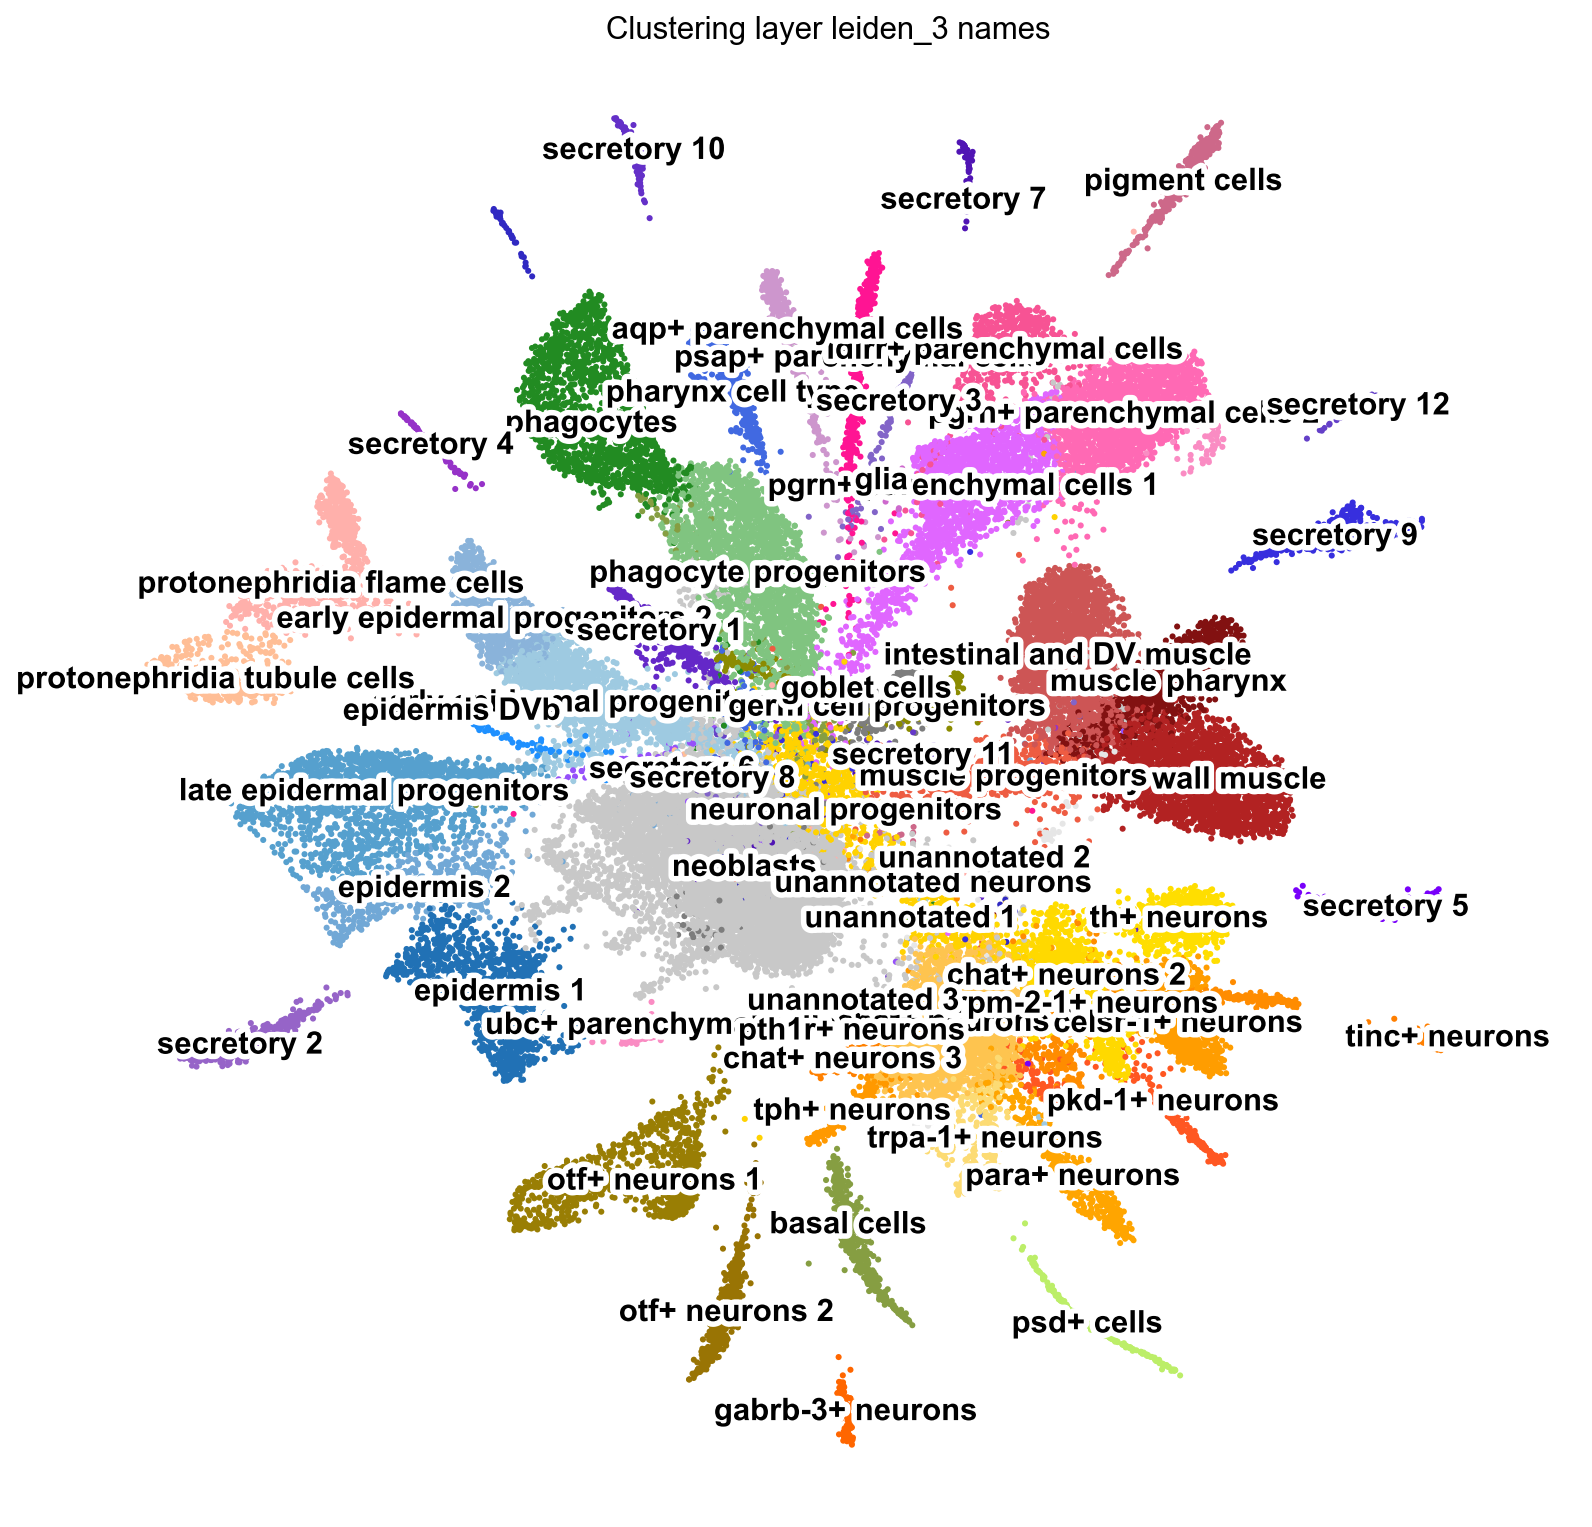

In [45]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color='leiden_3_names_collapsed', legend_loc='on data', legend_fontoutline = 5,
               title= 'Clustering layer '+str(clusteringlayer)+ ' names', size = 30,
               palette = cc_unique,
               frameon=False)

In [46]:
list(adata.uns)

['biological_replicates',
 'dendrogram_leiden_1',
 'dendrogram_leiden_2',
 'dendrogram_leiden_3',
 'dendrogram_leiden_4',
 'hvg',
 'ingest_names_colors',
 'leiden',
 'leiden_1_colors',
 'leiden_2_colors',
 'leiden_3_colors',
 'leiden_4_colors',
 'library_colors',
 'log1p',
 'neighbors',
 'pca',
 'rank_genes_groups_logreg_leiden_1',
 'rank_genes_groups_logreg_leiden_2',
 'rank_genes_groups_logreg_leiden_3',
 'rank_genes_groups_logreg_leiden_4',
 'rank_genes_groups_wilcox_leiden_1',
 'rank_genes_groups_wilcox_leiden_2',
 'rank_genes_groups_wilcox_leiden_3',
 'rank_genes_groups_wilcox_leiden_4',
 'sample_colors',
 'samples',
 'technical_replicates',
 'transferred_colors',
 'umap',
 'leiden_3_names_colors',
 'leiden_3_names_collapsed_colors']

In [47]:
adata.write(results_file)

In [48]:
list(adata.uns['leiden_3_names_collapsed_colors'])

['#c8c8c8',
 '#fec44f',
 '#b22222',
 '#cd5555',
 '#80c480',
 '#ff69b4',
 '#e066ff',
 '#56a0ce',
 '#9ecae1',
 '#228b22',
 '#821111',
 '#2171b5',
 '#ffd200',
 '#ffd900',
 '#997e04',
 '#ffb0ab',
 '#8ab3da',
 '#ff9d00',
 '#ffde00',
 '#6428c8',
 '#ff1493',
 '#f75394',
 '#869e42',
 '#ee5c42',
 '#71a8d6',
 '#ffa500',
 '#4169e1',
 '#9664c8',
 '#997404',
 '#7d7d7d',
 '#cd6889',
 '#ffbe96',
 '#cd96cd',
 '#ff8c00',
 '#372fde',
 '#fcdb74',
 '#ff5722',
 '#ff7f00',
 '#8b8b00',
 '#7800fa',
 '#8264c8',
 '#ff9900',
 '#bcee68',
 '#ff8000',
 '#1e90ff',
 '#fa8cc3',
 '#ff6600',
 '#6430c8',
 '#5014b4',
 '#9650fa',
 '#6438c8',
 '#3029c2',
 '#e6e6e6',
 '#9632c8',
 '#cd69cd',
 '#6440c8',
 '#ff8400',
 '#e6e6e6',
 '#e6e6e6',
 '#e6e6e6']